# Quran Translation — Exploratory Data Analysis

Analysis of the **English Saheeh International** translation (`translation_id=20`)
of the Quran, 6,236 verses across 114 chapters.

> **Scope note:** all findings describe an *English translation*, not the Arabic
> source text. Word counts, frequencies, and lengths are properties of the
> translation's prose.

Analysis logic lives in the reusable `quran_analysis` package; this notebook is a
thin presentation layer over `quran_analysis.eda` and `quran_analysis.text`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

# Resolve repo root by walking up to the directory containing data/, so the
# notebook works whether launched from repo root or notebooks/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
sys.path.insert(0, str(ROOT / "src"))

from quran_analysis import eda

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = eda.load_verses(ROOT / "data/processed/verses_translation_20.parquet")
df.shape

(6236, 27)

In [2]:
# Derived text columns:
#   clean_text       - footnotes/markup stripped, KEEPS [translator interpolations]
#   scripture_text   - interpolations removed (directly-rendered words only)
#   word_count / scripture_word_count - token counts for each variant
df[["verse_key", "clean_text", "scripture_text", "word_count", "scripture_word_count"]].head()

,verse_key,clean_text,scripture_text,word_count,scripture_word_count
0,1:1,"In the name of Allāh, the Entirely Merciful, t...","In the name of Allāh, the Entirely Merciful, t...",11,11
1,1:2,"All praise is due to Allāh, Lord of the worlds -","praise is to Allāh, Lord of the worlds -",10,8
2,1:3,"The Entirely Merciful, the Especially Merciful,","The Entirely Merciful, the Especially Merciful,",6,6
3,1:4,Sovereign of the Day of Recompense.,Sovereign of the Day of Recompense.,6,6
4,1:5,It is You we worship and You we ask for help.,It is You we worship and You we ask for help.,11,11


## Area 1 — Data Quality

Establish that the dataset is complete and understand its text-cleaning needs
before measuring anything.

In [3]:
# Headline integrity checks.
eda.data_quality_report(df)

total_verses                  6236
unique_chapters                114
null_translation                 0
empty_translation                0
duplicate_translation_text     126
verses_with_footnotes         1612
total_footnotes               1903
verses_with_brackets          3409
Name: data_quality, dtype: int64

In [4]:
# Verse counts per chapter vs the chapter metadata's expected count.
# An empty result below means every chapter has exactly the expected verses.
integrity = eda.verse_count_integrity(df)
mismatches = integrity.loc[~integrity["matches"]]
print(f"{len(mismatches)} / {len(integrity)} chapters mismatch expected verse counts")
mismatches

0 / 114 chapters mismatch expected verse counts


,chapter_id,chapter_name_simple,expected_verses,observed_verses,matches


In [5]:
# The 126 "duplicate" verse texts are legitimate refrains, not data errors.
# Ar-Rahman's recurring rhetorical question dominates.
eda.duplicate_examples(df).head(8)[["repeats", "verse_keys", "clean_text"]]

,repeats,verse_keys,clean_text
0,24,"[55:13, 55:16, 55:18, 55:21, 55:23, 55:25, 55:...",So which of the favors of your Lord would you ...
1,10,"[77:15, 77:19, 77:24, 77:28, 77:34, 77:37, 77:...","Woe, that Day, to the deniers."
2,8,"[26:9, 26:68, 26:104, 26:122, 26:140, 26:159, ...","And indeed, your Lord - He is the Exalted in M..."
3,7,"[55:38, 55:47, 55:57, 55:63, 55:71, 55:73, 55:75]",So which of the favors of your Lord would you ...
4,7,"[40:1, 41:1, 42:1, 43:1, 44:1, 45:1, 46:1]","Ḥā, Meem."
5,7,"[26:108, 26:126, 26:131, 26:144, 26:150, 26:16...",So fear Allāh and obey me.
6,6,"[26:8, 26:67, 26:103, 26:121, 26:174, 26:190]","Indeed in that is a sign, but most of them wer..."
7,6,"[2:1, 3:1, 29:1, 30:1, 31:1, 32:1]","Alif, Lām, Meem."


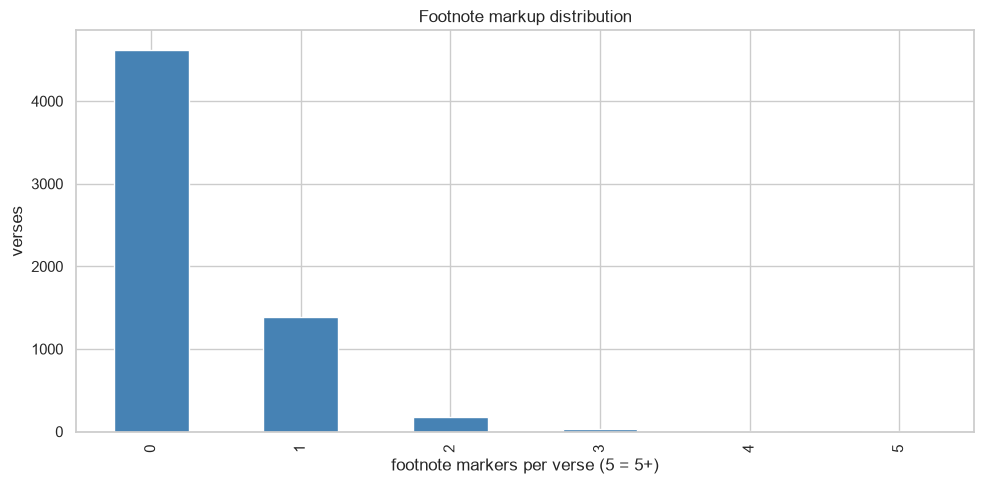

In [6]:
# Footnote markup coverage (now stripped from clean_text).
ax = (
    df["footnote_count"].clip(upper=5)
    .value_counts().sort_index()
    .plot(kind="bar", color="steelblue")
)
ax.set(xlabel="footnote markers per verse (5 = 5+)", ylabel="verses",
       title="Footnote markup distribution")
plt.tight_layout()

In [7]:
# Translator interpolations: 55% of verses contain [bracketed] clarifications,
# adding ~6.5% to the total word count. We keep both variants so each downstream
# analysis can choose its basis.
total = df["word_count"].sum()
scripture = df["scripture_word_count"].sum()
print(f"With interpolations : {total:,} words")
print(f"Scripture-only      : {scripture:,} words")
print(f"Interpolations add  : {total - scripture:,} words ({(total - scripture) / total:.1%})")

With interpolations : 159,867 words
Scripture-only      : 149,553 words
Interpolations add  : 10,314 words (6.5%)


**Area 1 takeaways**

- Dataset is **complete and clean**: 6,236 verses, 114 chapters, zero verse-count
  mismatches, no null/empty translations.
- Two cleaning concerns handled: `<sup>` footnote markup (1,612 verses) and
  `[bracketed]` translator interpolations (55% of verses, ~6.5% of words).
- "Duplicate" texts are real refrains (e.g. Ar-Rahman ×24), not errors.

## Area 2 — Structural Overview

### Thread A — Ordering: chronological vs canonical

The Quran's 114 chapters are **not** arranged in the order they were revealed.
Here we quantify how they *are* arranged, how far that departs from chronology,
and whether any alternate (e.g. ring/concentric) structure is detectable.

In [8]:
order = eda.ordering_table(df)   # chapter_id, revelation_order, verses, displacement, ...

# Q1: the book is arranged roughly longest-chapter-first.
rho = order["chapter_id"].corr(order["verses"], method="spearman")
print(f"Spearman(canonical position, chapter length) = {rho:.3f}  (strong 'longest-first')")
for lo, hi, lbl in [(1, 38, "first third"), (39, 76, "middle third"), (77, 114, "last third")]:
    seg = order[order.chapter_id.between(lo, hi)]
    print(f"  {lbl:13s} (ch {lo:>3}-{hi:<3}): median {seg.verses.median():5.1f} verses")

Spearman(canonical position, chapter length) = -0.845  (strong 'longest-first')
  first third   (ch   1-38 ): median  98.5 verses
  middle third  (ch  39-76 ): median  37.5 verses
  last third    (ch  77-114): median  11.0 verses


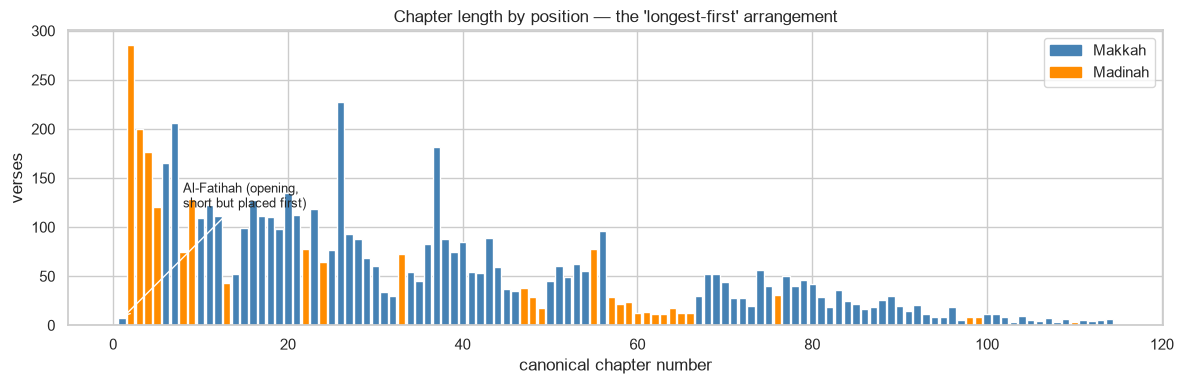

In [9]:
# Q1 visual: chapter length by canonical position, with the longest-first trend.
fig, ax = plt.subplots(figsize=(12, 4))
colors = order["revelation_place"].map({"makkah": "steelblue", "madinah": "darkorange"})
ax.bar(order["chapter_id"], order["verses"], color=colors, width=0.85)
ax.set(xlabel="canonical chapter number", ylabel="verses",
       title="Chapter length by position — the 'longest-first' arrangement")
ax.annotate("Al-Fatihah (opening,\nshort but placed first)", xy=(1, 7), xytext=(8, 120),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue", label="Makkah"), Patch(color="darkorange", label="Madinah")])
plt.tight_layout()

In [10]:
# Q2: displacement between revelation order and canonical position.
# Largest movers are Madinan chapters revealed late but placed near the front.
movers = order.reindex(order["displacement"].abs().sort_values(ascending=False).index).head(6)
print(movers[["chapter_id", "name", "revelation_place", "revelation_order", "displacement", "verses"]].to_string(index=False))
print()
print("Mean signed displacement by revelation place:")
print(order.groupby("revelation_place", observed=True)["displacement"].mean().round(1).to_string())

 chapter_id       name revelation_place  revelation_order  displacement  verses
          5 Al-Ma'idah          madinah               112           107     120
        111   Al-Masad           makkah                 6          -105       5
          9  At-Tawbah          madinah               113           104     129
         96   Al-'Alaq           makkah                 1           -95      19
        114     An-Nas           makkah                21           -93       6
        108 Al-Kawthar           makkah                15           -93       3

Mean signed displacement by revelation place:
revelation_place
madinah    53.4
makkah    -17.4


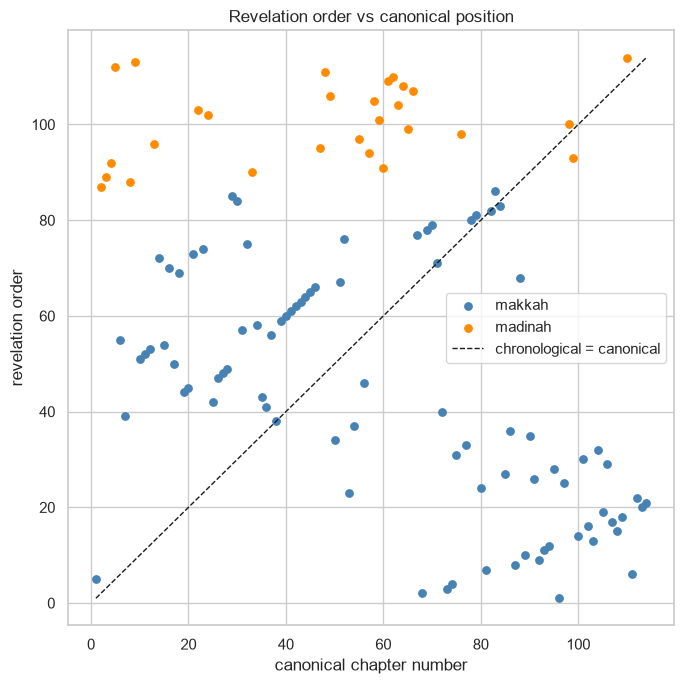

In [11]:
# Q2 visual: revelation order vs canonical position. Distance from the diagonal
# is the displacement; Madinan chapters sit far above it (revealed late, placed early).
fig, ax = plt.subplots(figsize=(7, 7))
for place, c in [("makkah", "steelblue"), ("madinah", "darkorange")]:
    s = order[order.revelation_place == place]
    ax.scatter(s["chapter_id"], s["revelation_order"], c=c, label=place, s=28)
ax.plot([1, 114], [1, 114], "k--", lw=1, label="chronological = canonical")
ax.set(xlabel="canonical chapter number", ylabel="revelation order",
       title="Revelation order vs canonical position")
ax.legend()
plt.tight_layout()

In [12]:
# Q3 (data caveat): in this dataset revelation_order does NOT interleave Makkah/Madinah.
mak = order[order.revelation_place == "makkah"]["revelation_order"]
mad = order[order.revelation_place == "madinah"]["revelation_order"]
print(f"Makkah revelation orders: {mak.min()}-{mak.max()}")
print(f"Madinah revelation orders: {mad.min()}-{mad.max()}")
print("=> all Makkan chapters precede all Madinan ones: revelation_order is a COARSE")
print("   traditional sequence (place-grouped), not a fine verse-level chronology.")

Makkah revelation orders: 1-86
Madinah revelation orders: 87-114
=> all Makkan chapters precede all Madinan ones: revelation_order is a COARSE
   traditional sequence (place-grouped), not a fine verse-level chronology.


In [13]:
# Q4: chronology is partly preserved locally in the canonical order.
seq = order["revelation_order"].to_numpy()
import numpy as np
lag1 = np.corrcoef(seq[:-1], seq[1:])[0, 1]
print(f"lag-1 autocorrelation of revelation order along canonical sequence = {lag1:.3f}")
print("Makkah/Madinah run-clustering:", eda.place_runs(df))
print("(far fewer runs than the random expectation => same-origin chapters cluster)")

lag-1 autocorrelation of revelation order along canonical sequence = 0.437
Makkah/Madinah run-clustering: {'observed_runs': 25, 'expected_runs_if_random': 43.2}
(far fewer runs than the random expectation => same-origin chapters cluster)


### Alternate structures — ring / concentric composition

Scholars (e.g. Farrin; Cuypers' *Semitic rhetoric*) argue some chapters are
arranged as **rings** — section A mirrors section A′ around a thematic center.
We test this on **Al-Baqarah** (the classic example) using *motif profiles*: each
section is scored over curated theme lexicons, and we check whether mirror-position
sections are more alike than a shuffled null allows.

> Caveat: this operates on the **English translation** and coarse sections. Ring
> arguments rest on Arabic verbal echoes and human-identified motifs, so a null
> here is **not** a refutation — only evidence that the pattern isn't detectable
> by these surface methods.

In [14]:
from quran_analysis import themes

baqarah = df[df.chapter_id == 2]
rukus = baqarah.groupby("ruku_number")["clean_text"].apply(" ".join).tolist()
nine = [" ".join(g) for g in np.array_split(baqarah["clean_text"].tolist(), 9)]

for label, units in [("40 ruku units", rukus), ("9 equal sections", nine)]:
    res = eda.ring_test(themes.motif_profiles(units))
    print(f"{label:18s}: mirror={res['mirror_similarity']:.3f}  "
          f"null={res['null_mean']:.3f}  z={res['z']:+.2f}  p={res['p_value']:.3f}")
print()
print("z ~ 0 and p ~ 0.5 at both granularities => no detectable concentric symmetry.")

40 ruku units     : mirror=0.445  null=0.451  z=-0.17  p=0.549
9 equal sections  : mirror=0.694  null=0.693  z=+0.02  p=0.493

z ~ 0 and p ~ 0.5 at both granularities => no detectable concentric symmetry.


**Thread A takeaways**

- **Arrangement is by length, not chronology**: Spearman(position, length) = −0.85;
  median chapter length falls 98.5 → 37.5 → 11 verses across the three thirds.
  Al-Fatihah is the deliberate short-but-first exception (the opening).
- **The big order-shifts are systematically Madinan** — Al-Ma'idah (+107) and
  At-Tawbah (+104) were revealed last but placed near the front.
- **Data caveat**: `revelation_order` here is place-grouped (all Makkan 1–86,
  all Madinan 87–114), so treat it as a coarse sequence, not a fine timeline.
- **Local chronology survives** in the canonical order (lag-1 autocorr 0.44;
  25 origin-runs vs ~43 expected) — same-origin chapters cluster.
- **Ring structure**: not detectable in Al-Baqarah via motif profiles on the
  English translation (z ≈ 0). A fair test of the scholarly claim needs Arabic
  roots / verbal-echo tracking.